In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/bank_transactions_data_2.csv")

df.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,2024-11-04 08:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06,2024-11-04 08:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40,2024-11-04 08:06:39


In [4]:
print("Shape:", df.shape)
df.info()

Shape: (2512, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2512 non-null   object 
 1   AccountID                2512 non-null   object 
 2   TransactionAmount        2512 non-null   float64
 3   TransactionDate          2512 non-null   object 
 4   TransactionType          2512 non-null   object 
 5   Location                 2512 non-null   object 
 6   DeviceID                 2512 non-null   object 
 7   IP Address               2512 non-null   object 
 8   MerchantID               2512 non-null   object 
 9   Channel                  2512 non-null   object 
 10  CustomerAge              2512 non-null   int64  
 11  CustomerOccupation       2512 non-null   object 
 12  TransactionDuration      2512 non-null   int64  
 13  LoginAttempts            2512 non-null   int64  
 14  Accoun

In [5]:
print("Missing Values:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())

Missing Values:
 TransactionID              0
AccountID                  0
TransactionAmount          0
TransactionDate            0
TransactionType            0
Location                   0
DeviceID                   0
IP Address                 0
MerchantID                 0
Channel                    0
CustomerAge                0
CustomerOccupation         0
TransactionDuration        0
LoginAttempts              0
AccountBalance             0
PreviousTransactionDate    0
dtype: int64

Duplicates: 0


In [6]:
df.drop_duplicates(inplace=True)

df["TransactionDate"] = pd.to_datetime(
    df["TransactionDate"], dayfirst=True, errors="coerce"
)

df["PreviousTransactionDate"] = pd.to_datetime(
    df["PreviousTransactionDate"], dayfirst=True, errors="coerce"
)

In [8]:
df.drop_duplicates(inplace=True)

df["TransactionDate"] = pd.to_datetime(
    df["TransactionDate"], dayfirst=True, errors="coerce"
)

df["PreviousTransactionDate"] = pd.to_datetime(
    df["PreviousTransactionDate"], dayfirst=True, errors="coerce"
)

In [7]:
df["YearMonth"] = df["TransactionDate"].dt.to_period("M").astype(str)

df["AgeGroup"] = pd.cut(
    df["CustomerAge"],
    bins=[17, 25, 35, 45, 55, 65, 100],
    labels=["18-25", "26-35", "36-45", "46-55", "56-65", "65+"]
)

In [9]:
print("Total Transactions:", df["TransactionID"].nunique())
print("Total Accounts:", df["AccountID"].nunique())
print("Total Transaction Value:", round(df["TransactionAmount"].sum(), 2))
print("Average Transaction:", round(df["TransactionAmount"].mean(), 2))
print("Average Balance:", round(df["AccountBalance"].mean(), 2))

Total Transactions: 2512
Total Accounts: 495
Total Transaction Value: 747555.57
Average Transaction: 297.59
Average Balance: 5114.3


In [10]:
df.groupby("TransactionType")["TransactionAmount"].agg(
    ["count", "sum", "mean"]
).round(2)

,count,sum,mean
TransactionType,,,
Credit,568,174092.57,306.50
Debit,1944,573463.00,294.99


In [11]:
df.groupby("Channel")["TransactionAmount"].agg(
    ["count", "sum", "mean"]
).round(2)

,count,sum,mean
Channel,,,
ATM,833,256331.43,307.72
Branch,868,250183.00,288.23
Online,811,241041.14,297.21


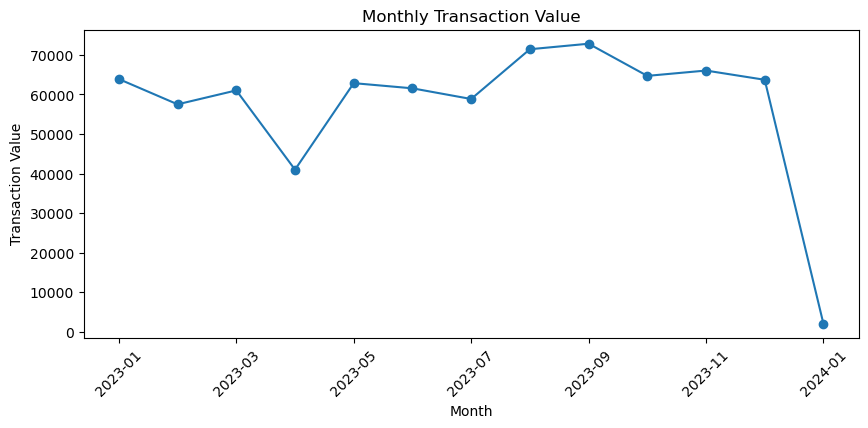

In [12]:
monthly = df.groupby("YearMonth")["TransactionAmount"].sum()

monthly.plot(figsize=(10, 4), marker="o")
plt.title("Monthly Transaction Value")
plt.xlabel("Month")
plt.ylabel("Transaction Value")
plt.xticks(rotation=45)
plt.show()

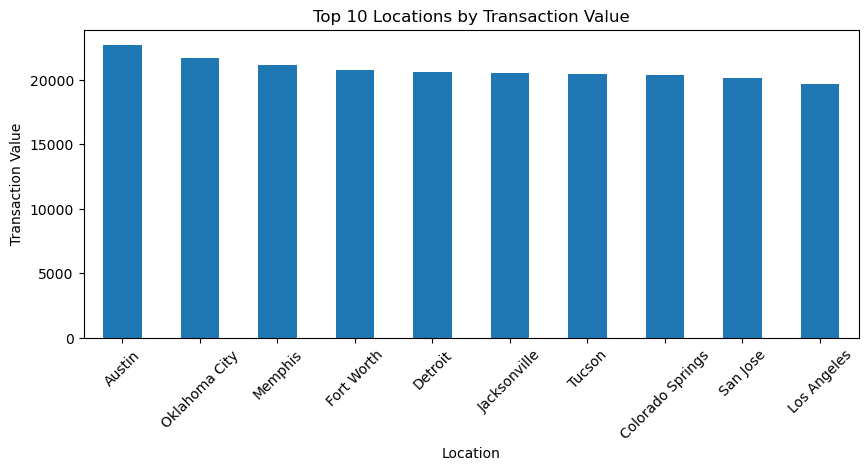

In [13]:
top_locations = df.groupby("Location")["TransactionAmount"].sum().nlargest(10)

top_locations.plot(kind="bar", figsize=(10, 4))
plt.title("Top 10 Locations by Transaction Value")
plt.ylabel("Transaction Value")
plt.xticks(rotation=45)
plt.show()

In [14]:
accounts = df.groupby("AccountID").agg(
    Transactions=("TransactionID", "count"),
    TotalAmount=("TransactionAmount", "sum"),
    AvgBalance=("AccountBalance", "mean")
).reset_index()

accounts.sort_values("TotalAmount", ascending=False).head(10)

,AccountID,Transactions,TotalAmount,AvgBalance
455,AC00460,12,5570.34,4887.100833
358,AC00363,12,4702.91,5502.639167
333,AC00337,8,4393.41,4463.382500
20,AC00021,8,4263.34,3631.391250
434,AC00439,9,4185.81,5329.817778
380,AC00385,7,4141.20,2371.364286
69,AC00071,8,4050.12,1760.048750
261,AC00265,9,3953.60,5747.238889
134,AC00136,8,3880.53,5374.211250
177,AC00179,6,3819.73,8851.878333


In [15]:
accounts["Segment"] = pd.qcut(
    accounts["TotalAmount"],
    3,
    labels=["Low Value", "Medium Value", "High Value"]
)

accounts["Segment"].value_counts()

Low Value       165
Medium Value    165
High Value      165
Name: Segment, dtype: int64

In [16]:
df.groupby("AgeGroup", observed=True)["TransactionAmount"].agg(
    ["count", "sum", "mean"]
).round(2)

,count,sum,mean
AgeGroup,,,
18-25,475,150054.76,315.90
26-35,486,149752.63,308.13
36-45,303,85293.42,281.50
46-55,432,118403.62,274.08
56-65,449,138824.08,309.19
65+,367,105227.06,286.72


In [17]:
df.groupby("CustomerOccupation")["TransactionAmount"].agg(
    ["count", "sum", "mean"]
).sort_values("sum", ascending=False).round(2)

,count,sum,mean
CustomerOccupation,,,
Student,657,205786.03,313.22
Doctor,631,184693.81,292.70
Engineer,625,180650.06,289.04
Retired,599,176425.67,294.53


In [18]:
df.to_csv("../data/bank_transactions_cleaned.csv", index=False)
accounts.to_csv("../data/account_summary.csv", index=False)

print("Files saved successfully")

Files saved successfully
